In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
from io import StringIO
from datetime import datetime
import matplotlib.pyplot as plt
from statistics import mean, stdev

In [26]:
'''
def calculate_time_stats(time_diffs):
    # figure out condition
    print(mean(time_diffs))

def calculate_diff(time):

    # complicated list comprehension to convert time formatted like "2025-01-21 16:24:53.062630"
    # into a single timestamp float 1737505492.872748
    time = [datetime.strptime(t, "%Y-%m-%d %H:%M:%S.%f").timestamp() for t in time]
    # time_in_s = [t/10**6 for t in time] # converting from microseconds to seconds
    all_diffs = []
    
    # calculate time differences between keystrokes
    for i, curr_t in enumerate(time):
        if i >= len(time)-1:
            return all_diffs
        diff = time[i+1] - curr_t
        all_diffs.append(diff) 
'''  
special_characters = {
    'À'     : 'BACKTICK',
    '\x10À' : 'SQUIGGLE',
    '\x101' : 'EXCLAMATIONPOINT',
    '\x103' : 'HASHMARK',
    '\x104' : 'DOLLARSIGN',
    '\x105' : 'PERCENT',
    '\x106' : 'CARET',
    '\x107' : 'AMPERSAND',   
    '\x108' : 'STAR',
    '\x109' : 'LEFTPARENTHESIS',
    '\x100' : 'RIGHTPARENTHESIS',
    '½'     : 'MINUS',
    '\x10»' : 'PLUS',
    '»'     : 'EQUALS',
    '\x08'  : 'BACKSPACE',
    '\t'    : 'TAB',
    'Û'     : 'LEFTBRACKET',
    'Ý'     : 'RIGHTBRACKET',
    '\x10Û' : 'LEFTBRACE',
    '\x10Ý' : 'RIGHTBRACE',
    'Ü'     : 'BACKSLASH',
    '\x10Ü' : 'VERTICALLINE',
    'º'     : 'SEMICOLON',
    '\x10º' : 'COLON',
    'Þ'     : 'SINGLEQUOTE',
    '\x10Þ' : 'DOUBLEQUOTE',
    '\r'    : 'ENTER',
    '\x10'  : 'SHIFT',
    '¼'     : 'COMMA',
    '¾'     : 'PERIOD',
    '\x10¼' : 'LESSTHAN',
    '\x10¾' : 'GREATERTHAN',
    '¿'     : 'FORWARDSLASH',
    '\x10¿' : 'QUESTIONMARK',
    '\x11'  : 'CONTROL',
    '\x1b'  : 'ESCAPE',
    '%'     : 'LEFTARROW',
    "'"     : 'RIGHTARROW',
    '&'     : 'UPARROW',
    '('     : 'DOWNARROW'
}
        
# Read and split the file
def process_txt_files(path):
    with open(path, 'r') as f:
        lines = f.readlines()

    # Initialize list to hold each chunk of keystrokes
    chunks = []
    current_chunk = []

    for line in lines:
        line = line.strip()
        if line.lower() == 'new stimulus':
            if current_chunk:
                chunks.append(current_chunk)
                current_chunk = []
        else:
            current_chunk.append(line)

    # Add the last chunk if it's not empty
    if current_chunk:
        chunks.append(current_chunk)
    return chunks

def calculate_keystroke_sparsity(time):
    time = [float(t)//10**3 for t in time]
    total_time = time[-1] - time[0]
    scaled_time = np.array([t - time[0] for t in time])
    
    when_keystrokes = np.zeros(round(total_time))
    for i in range(round(total_time)-1):
        time_range = (scaled_time > i) & (scaled_time <= i+1)
        if len(np.where(time_range)[0]) > 0:
            when_keystrokes[i] = 1
    return when_keystrokes

def process_raw_keystrokes(keystrokes):
    processed = []
    for k in keystrokes:
        asci_int = int(k)
        asci_chr = chr(asci_int)
        try:
            asci_chr = special_characters[asci_chr]
        except:
            y = "carry on"
        processed.append(ascii_chr)
    return processed


def read_keytrokes(df):

    # df = pd.read_csv(filepath, header=None, names = ['time', 'ascii_key'], sep=', ')
    
    raw_keystrokes = df['ascii_key']
    # print(list(raw_keystrokes))
    # keystrokes = process_raw_keystrokes(raw_keystrokes)
    time = df['time']
    
    sparsity = calculate_keystroke_sparsity(time)
    # print(time)
    # time_diffs = calculate_diff(list(time))
    ascii_nums = df['ascii_key']
    return list(ascii_nums), sparsity

In [28]:
# keystrokes
folders = os.listdir("test_data")

code_sparsity = []
prose_sparsity = []

for participant in folders:
    print(participant)
    keypath = f'test_data/{participant}/keystrokes'
    
    try:
        keyfolder = os.listdir(keypath)
    except:
        print('no keystrokes')
        continue
    for file in keyfolder:
        print(file)
        path = f"{keypath}/{file}" 
        
        keystroke_files = process_txt_files(path)
        for j in keystroke_files:
            print(j)
        for f in keystroke_files:
            split_columns = [row.split(', ') for row in f]
            df = pd.DataFrame(split_columns, columns=['time', 'ascii_key'])
            df['time'] = df['time'].astype(float)
            df['ascii_key'] = df['ascii_key'].astype(int)
            print(df)
            # print(type(df), type(df.loc[0, 'time']), type(df.loc[0,'ascii_key']), df)
            # df['time'] = df['time'].apply(lambda row : float(row['time']))
            # df['ascii_key'] = df['ascii_key'].apply(lambda row : int(row['ascii_key']))
            ascii_nums, sparsity = read_keytrokes(df)
        
        if re.search('-3', file):
            code_sparsity.append(sparsity)
            # print(f"should be code writing from old experiment: {file}")
        elif re.search('-1', file):
            prose_sparsity.append(sparsity)
            # print(f"should be prose writing from old experiment: {file}")
        # break  

117
keystrokes-117-3.txt
['78185559.361474, 79', '78185773.432642, 78', '78186260.382581, 16', '78186388.283199, 79', '78187181.971797, 8', '78188403.846564, 8', '78188782.42749, 8', '78189776.159144, 66', '78189904.068918, 79', '78190055.046039, 79', '78190344.632262, 76', '78190560.354367, 32', '78191000.821446, 79', '78191133.895426, 78', '78191406.537833, 16', '78191614.452179, 79', '78191950.284066, 70', '78192117.395763, 70', '78192456.350033, 16', '78192808.084016, 83', '78193129.112397, 87', '78193230.419914, 73', '78193351.011299, 84', '78193615.557705, 67', '78193702.194878, 72', '78193917.566877, 16', '78193997.541487, 57', '78194126.228042, 48', '78195221.672803, 8', '78196030.599627, 66', '78196135.131896, 79', '78196285.221822, 79', '78196901.727477, 76', '78197157.382236, 32', '78197405.877847, 83', '78197597.50864, 87', '78197711.372269, 73', '78197846.971621, 84', '78198086.957595, 67', '78198191.206615, 72', '78198365.209748, 16', '78198592.532525, 173', '78199389.704

In [30]:
def create_carpet_plot(arrays, title):
    # Find the maximum length to pad all arrays to the same size
    max_len = max(len(arr) for arr in arrays)

    # Pad the arrays with NaNs to make them the same length
    padded_arrays = np.full((len(arrays), max_len), np.nan)
    for i, arr in enumerate(arrays):
        padded_arrays[i, :len(arr)] = arr

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    cmap = plt.get_cmap('summer_r') # Wistia, 

    # Use `imshow` to create the carpet plot
    im = ax.imshow(padded_arrays, aspect='auto', cmap=cmap, interpolation='none')

    # Add colorbar
    cbar = plt.colorbar(im)
    cbar.set_label('Value')

    # Labels and formatting
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel('Trial')

    # plt.savefig(f'../figures/carpet_{title}.png', dpi=150)
    plt.show()

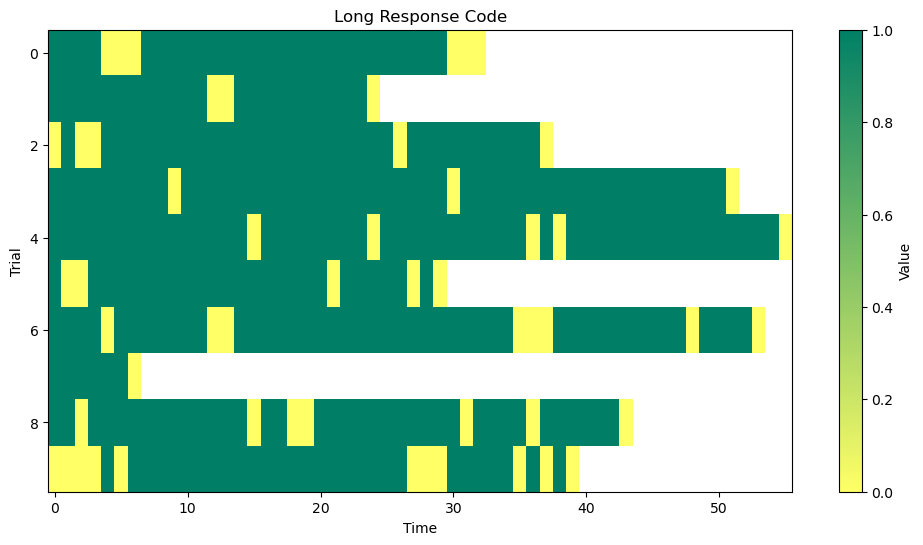

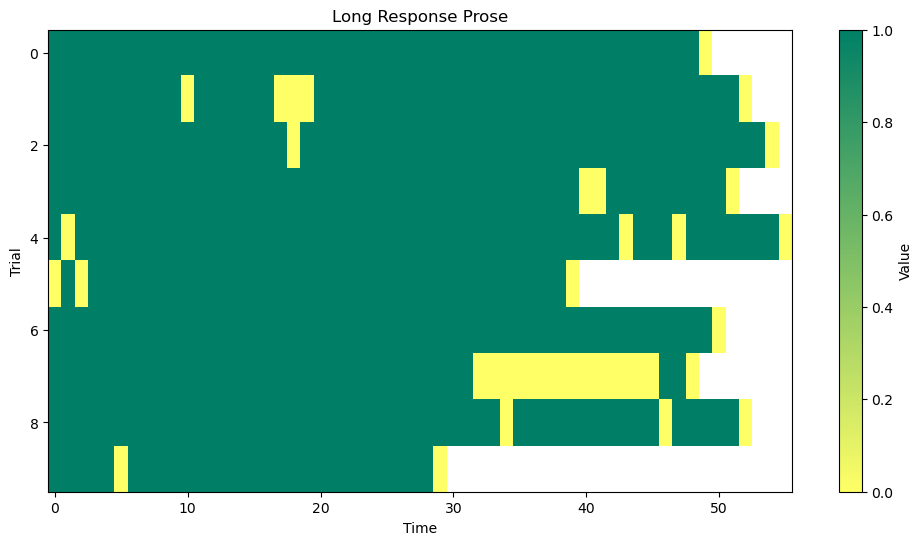

In [31]:
create_carpet_plot(code_sparsity, "Long Response Code")
create_carpet_plot(prose_sparsity, "Long Response Prose")
